# Deep Learning for Neuroimaging: Convolutional Neural Networks for Age-Related Brain Classification

In this notebook, we implemented convolutional neural networks (CNNs) on a publicly available structural MRI dataset (OASIS-1 VBM (voxel-based morphometry) grey-matter maps, n = 50 subjects, with age and gender information (auto-downloaded via nilearn)) to classify subjects as **younger (< 50 y) vs older (>= 50 y)** from grey-matter density maps. More specifically, we establish a classical baseline using whole-brain grey-matter density as features and a linear SVM; then we implemented a 2-D CNN (two-dimensional CNN) (`Conv2d`) to perform slice-based classification and a 3D CNN (`Conv3d`) to perform volumetric brain classification. Additionally, we adapted a pretrained ResNet-18 (ImageNet model) to MRI slices (transfer learning) and compared it with the 2-D CNN model.

<br>

In [1]:
# !pip install nilearn nibabel torch torchvision scikit-learn matplotlib seaborn tqdm

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

import nibabel as nib
import nilearn
from nilearn import datasets, plotting, image, connectome
from nilearn.maskers import NiftiLabelsMasker, NiftiMasker

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as transforms
import torchvision.models as tv_models

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch {torch.__version__}  |  nilearn {nilearn.__version__}  |  device: {DEVICE}')

PyTorch 2.10.0+cpu  |  nilearn 0.13.0  |  device: cpu


---

## 1. The Structural MRI Dataset (OASIS VBM)

Brain scans are most commonly stored as NIfTI (`.nii` / `.nii.gz`) files. A NIfTI volume is a 3-D (or 4-D for time-series fMRI) array plus an affine matrix that maps voxel indices to real-world coordinates (mm).

Here, we structural MRI/voxel-based morphometry (VBM)

In [3]:
#Downloading a small structural MRI dataset (OASIS VBM, ~n = 403 subjects):

#50 subjects requested (of 403 available):
oasis = datasets.fetch_oasis_vbm(n_subjects=50)   # grey-matter maps + age + gender

print('OASIS keys:', list(oasis.keys()))
print(f'Number of subjects : {len(oasis.gray_matter_maps)}')
print(f'Age range          : {oasis.ext_vars["age"].astype(float).min():.0f} – '
      f'{oasis.ext_vars["age"].astype(float).max():.0f} years')

[fetch_oasis_vbm] Dataset found in C:\Users\heito\nilearn_data\oasis1

OASIS keys: ['gray_matter_maps', 'white_matter_maps', 'ext_vars', 'data_usage_agreement', 'description']
Number of subjects : 50
Age range          : 18 – 89 years


In [4]:
#Inspecting one NIfTI volume with nibabel:

sample_path = oasis.gray_matter_maps[0]
img = nib.load(sample_path)

print('Shape:', img.shape)
print('Voxel size (mm):', np.diag(img.affine)[:3].round(2))
print('Data dtype:', img.get_fdata().dtype)

vol = img.get_fdata()
print(f'Intensity range: [{vol.min():.4f}, {vol.max():.4f}]')

Shape: (91, 109, 91)
Voxel size (mm): [-2.  2.  2.]
Data dtype: float64
Intensity range: [0.0000, 1.1909]


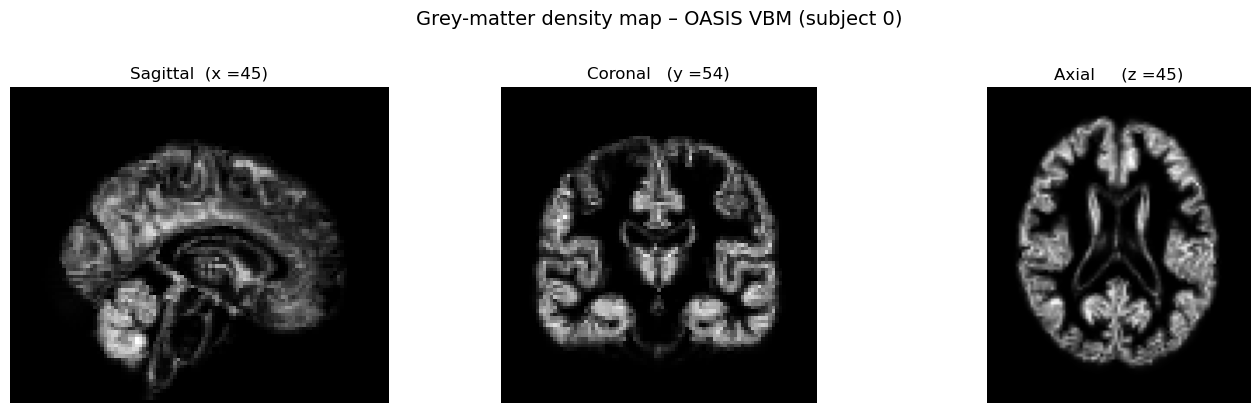

In [5]:
#Visualizing three orthogonal planes (sagittal, coronal, and axial orientations):

fig, axes = plt.subplots(1, 3, figsize = (14, 4))
mid = [s // 2 for s in vol.shape]

planes = [
    (vol[mid[0], :, :], f'Sagittal  (x ={mid[0]})'),
    (vol[:, mid[1], :], f'Coronal   (y ={mid[1]})'),
    (vol[:, :, mid[2]], f'Axial     (z ={mid[2]})'),]

for ax, (plane, title) in zip(axes, planes):
    ax.imshow(plane.T, cmap = 'gray', origin = 'lower')
    ax.set_title(title, fontsize = 12)
    ax.axis('off')

fig.suptitle('Grey-matter density map – OASIS VBM (subject 0)', fontsize = 14, y = 1.02)
plt.tight_layout()
plt.show()

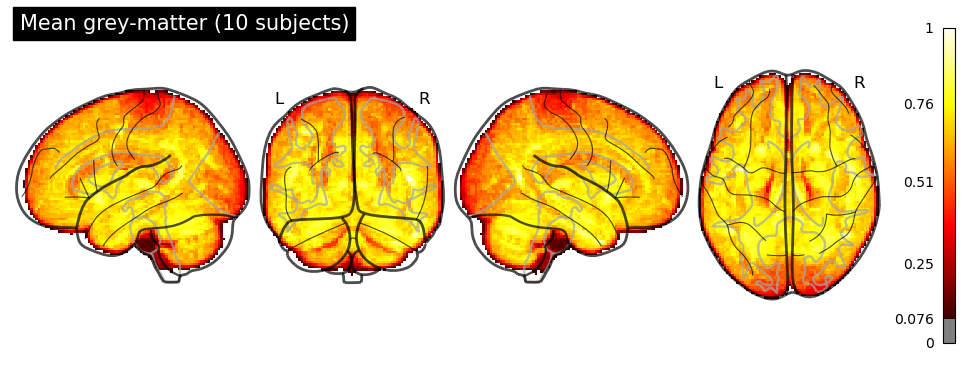

In [6]:
#Interactive glass-brain view with nilearn:

mean_img = image.mean_img(oasis.gray_matter_maps[:10])
plotting.plot_glass_brain(mean_img, title='Mean grey-matter (10 subjects)', colorbar = True,
                          display_mode='lyrz', cmap='hot')
plt.show()

---
## 2. Preprocessing Pipeline

Firstly, we note that raw scans need to be brought into a common space (MNI152) and smoothed before modelling, but for VBM data this is already done. We perform the following preprocessing pipeline: 

- Resampling images to a common spatial resolution -> Spatial Gaussian smoothing -> Brain masking -> Standardization and vectorization of voxel data.

In [7]:
#Resample all images to a common resolution

from nilearn.image import resample_img
import nibabel as nib

target_affine = np.diag([4, 4, 4, 1])   #4 mm isotropic target
resampled = resample_img(img, target_affine=target_affine, interpolation = 'continuous')
print(f'Original shape: {img.shape}  ->  Resampled shape: {resampled.shape}')

Original shape: (91, 109, 91)  ->  Resampled shape: (24, 24, 28)


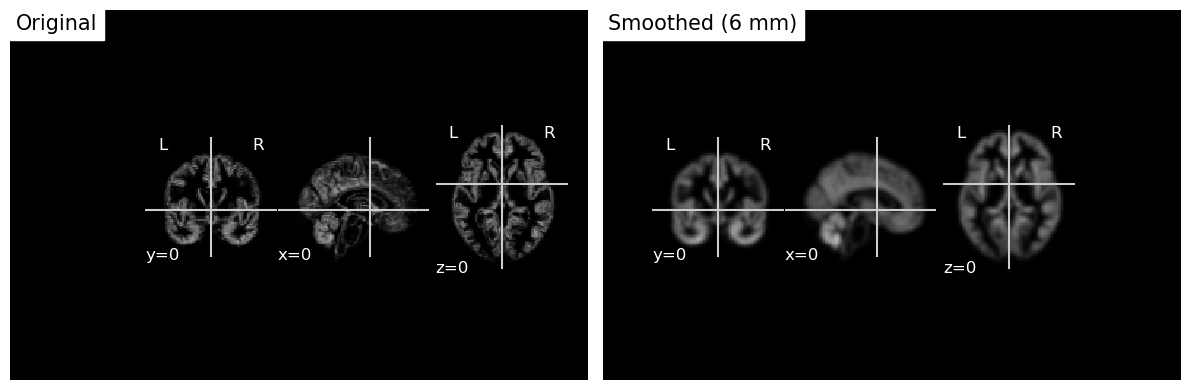

In [8]:
#Spatial smoothing (isotropic Gaussian kernel):
from nilearn.image import smooth_img

smoothed = smooth_img(img, fwhm = 6)   #6 mm FWHM kernel.

fig, axes = plt.subplots(1, 2, figsize = (12, 4))
for ax, (im, label) in zip(axes, [(img, 'Original'), (smoothed, 'Smoothed (6 mm)')]):
    plotting.plot_anat(im, axes = ax, title = label, cut_coords = (0, 0, 0),
                       display_mode = 'ortho', colorbar = False)
plt.tight_layout()
plt.show()

In [9]:
#Brain masking and vectorisation:

masker = NiftiMasker(
    mask_strategy = 'epi',
    smoothing_fwhm = 4,
    standardize = True,
    memory = 'nilearn_cache',
    verbose = 0,)

#Fit on all 50 subjects and transform to 2-D matrix  [n_subjects × n_voxels]:
X_voxels = masker.fit_transform(oasis.gray_matter_maps)
ages      = oasis.ext_vars['age'].astype(float)
print(f'Feature matrix shape: {X_voxels.shape}')   #(50, ~27 000)

Feature matrix shape: (50, 154067)


---
## 3. ML Baseline: Age Binarization with SVM

Before applying the CNN, we establish a classical baseline using whole-brain grey-matter density as features and a linear SVM.

In [10]:
#Binarize labels: Young (<50 y) vs Older (≥50 y)

y_age = (ages >= 50).astype(int)   #0 = Young, 1 = Older.
print(f'Young: {(y_age == 0).sum()}  |  Older: {(y_age == 1).sum()}')

Young: 23  |  Older: 27


In [11]:
#SVM cross-validation:

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='linear', C = 0.01, probability = True)) ])

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 8651)
scores = cross_val_score(pipeline, X_voxels, y_age, cv = cv, scoring = 'roc_auc', n_jobs = -1)

print(f'SVM (linear) 5-fold AUC: {scores.mean():.3f} ± {scores.std():.3f}')

SVM (linear) 5-fold AUC: 0.968 ± 0.039


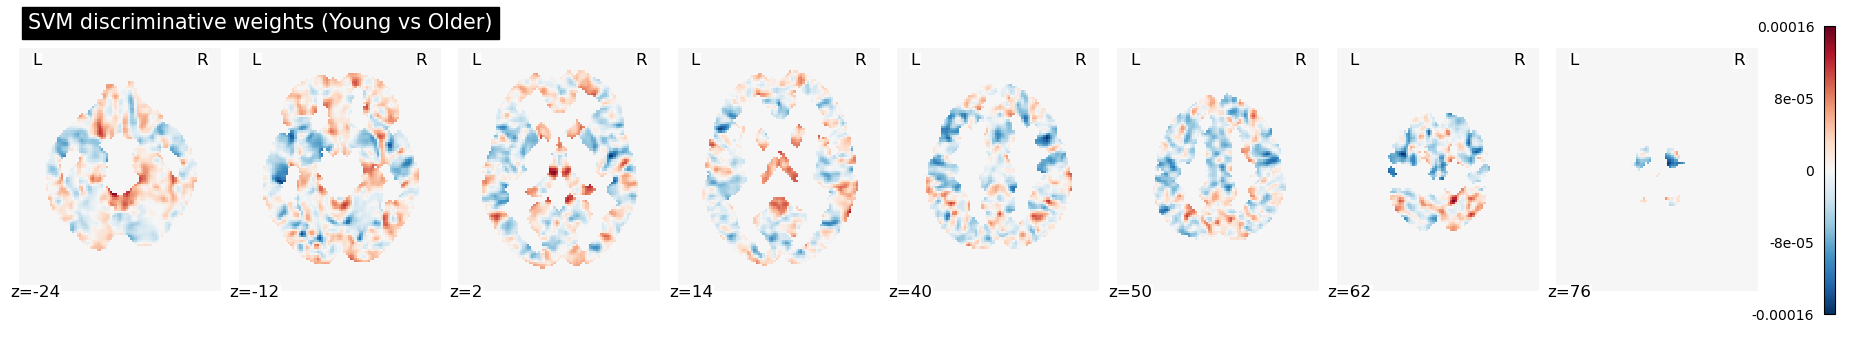

In [12]:
#Visualise SVM weights as a brain map:

pipeline.fit(X_voxels, y_age)
coef_img = masker.inverse_transform(pipeline.named_steps['svm'].coef_)

plotting.plot_stat_map(
    coef_img,
    title = 'SVM discriminative weights (Young vs Older)',
    threshold = 'auto',
    display_mode ='z',
    cut_coords = 8,
    colorbar = True,
    cmap = 'RdBu_r')

plt.show()

---
## 4. 2-D CNN on Brain Slices

One practical strategy is to treat individual axial slices as 2-D images and train a CNN on them. We build a small LeNet-style network and train on axial slices from the OASIS grey-matter maps.

In [13]:
#Build a slice dataset from OASIS VBM:

class BrainSliceDataset(Dataset):
    """Yield 2-D axial slices of grey-matter maps labelled by age group."""

    def __init__(self, img_paths, labels, slice_range = (20, 60), target_size = (64, 64)):
        self.records = []
        self.transform = transforms.Compose([
            transforms.ToTensor(),
            transforms.Resize(target_size, antialias = True),
            transforms.Normalize(mean = [0.5], std = [0.5]),])
        
        for path, label in zip(img_paths, labels):
            vol = nib.load(path).get_fdata().astype(np.float32)
            # Clip n_slices to available axial dimension
            z_max = min(slice_range[1], vol.shape[2])
            z_min = min(slice_range[0], z_max)
            for z in range(z_min, z_max, 4):   #stride = 4 for efficiency
                slc = vol[:, :, z]
                
                #Skip nearly-empty slices
                if slc.max() > 0.01:
                    slc = (slc - slc.min()) / (slc.max() - slc.min() + 1e-8)
                    self.records.append((slc, label))

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        slc, label = self.records[idx]
        
        #torchvision transforms expect H×W×C or H×W PIL/numpy
        slc_t = self.transform(slc[..., np.newaxis])
        return slc_t, torch.tensor(label, dtype = torch.long)


labels_oasis = y_age   #0 = Young, 1 = Older (defined earlier)
slice_ds = BrainSliceDataset(oasis.gray_matter_maps, labels_oasis)
print(f'Total slices: {len(slice_ds)}  |  Channels: {slice_ds[0][0].shape}')

Total slices: 500  |  Channels: torch.Size([1, 64, 64])


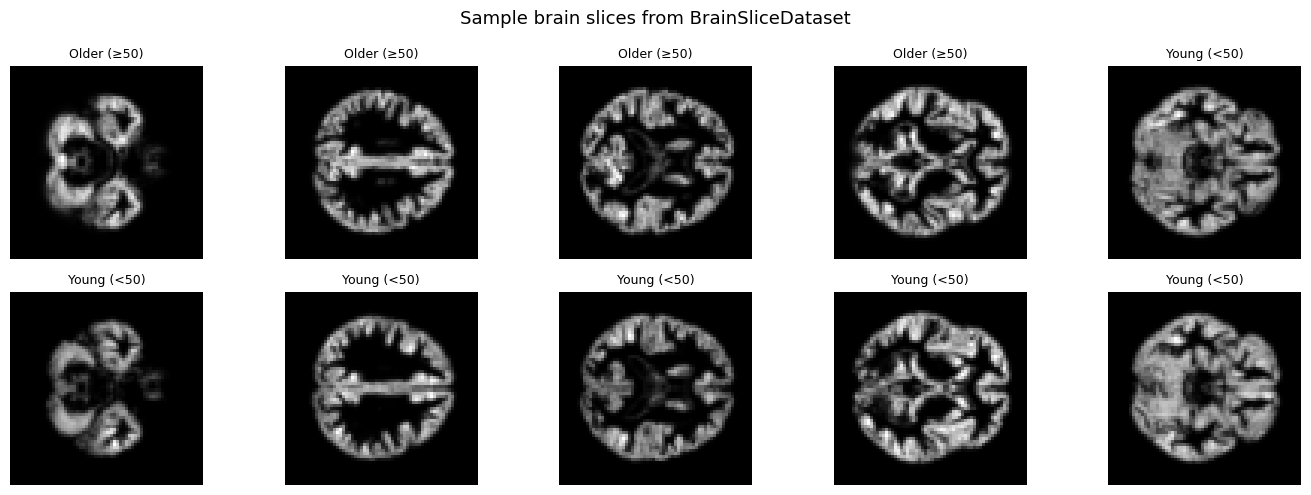

In [14]:
#Visualizing a few slices from the dataset:

fig, axes = plt.subplots(2, 5, figsize = (14, 5))
class_names = ['Young (<50)', 'Older (≥50)']

for i, ax in enumerate(axes.flat):
    img_t, lbl = slice_ds[i * 8]
    ax.imshow(img_t.squeeze().numpy(), cmap = 'gray')
    ax.set_title(class_names[lbl.item()], fontsize = 9)
    ax.axis('off')

fig.suptitle('Sample brain slices from BrainSliceDataset', fontsize = 13)
plt.tight_layout()
plt.show()

In [15]:
#Define a lightweight 2-D CNN (LeNet-style):

class BrainCNN2D(nn.Module):
    """2-D CNN for binary classification of brain slices."""

    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            #Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),     # 64→32
            nn.Dropout2d(0.25),
            #Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),     # 32→16
            nn.Dropout2d(0.25),
            #Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

cnn2d = BrainCNN2D()
print(f'Trainable parameters: {count_params(cnn2d):,}')

Trainable parameters: 664,546


In [16]:
#Train the 2-D CNN:

def train_model(model, dataset, epochs=25, batch_size=32, lr=3e-4, val_frac=0.2):
    n_val   = int(val_frac * len(dataset))
    n_train = len(dataset) - n_val
    train_ds, val_ds = random_split(dataset, [n_train, n_val],
                                    generator=torch.Generator().manual_seed(0))
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=0)

    model = model.to(DEVICE)
    opt   = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sched = optim.lr_scheduler.OneCycleLR(opt, max_lr=lr,
                                          steps_per_epoch=len(train_dl), epochs=epochs)
    loss_fn = nn.CrossEntropyLoss()

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    for ep in range(1, epochs + 1):
        #--- Train ---
        model.train()
        t_loss = 0.0
        for xb, yb in train_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            sched.step()
            t_loss += loss.item() * len(xb)

        #--- Validate ---
        model.eval()
        v_loss, correct = 0.0, 0
        with torch.no_grad():
            for xb, yb in val_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                v_loss  += loss_fn(logits, yb).item() * len(xb)
                correct += (logits.argmax(1) == yb).sum().item()

        history['train_loss'].append(t_loss / n_train)
        history['val_loss'].append(v_loss  / n_val)
        history['val_acc'].append(correct  / n_val)

        if ep % 5 == 0:
            print(f'  Epoch {ep:02d}/{epochs} '
                  f'train_loss={history["train_loss"][-1]:.4f}  '
                  f'val_loss={history["val_loss"][-1]:.4f}  '
                  f'val_acc={history["val_acc"][-1]:.3f}')

    return model, history


print('Training 2-D CNN…')
cnn2d, hist_cnn2d = train_model(BrainCNN2D(), slice_ds, epochs=25)

Training 2-D CNN…
  Epoch 05/25 train_loss=0.6823  val_loss=0.6670  val_acc=0.730
  Epoch 10/25 train_loss=0.6287  val_loss=0.7855  val_acc=0.510
  Epoch 15/25 train_loss=0.5165  val_loss=0.4799  val_acc=0.770
  Epoch 20/25 train_loss=0.4120  val_loss=0.4435  val_acc=0.810
  Epoch 25/25 train_loss=0.3928  val_loss=0.4243  val_acc=0.820


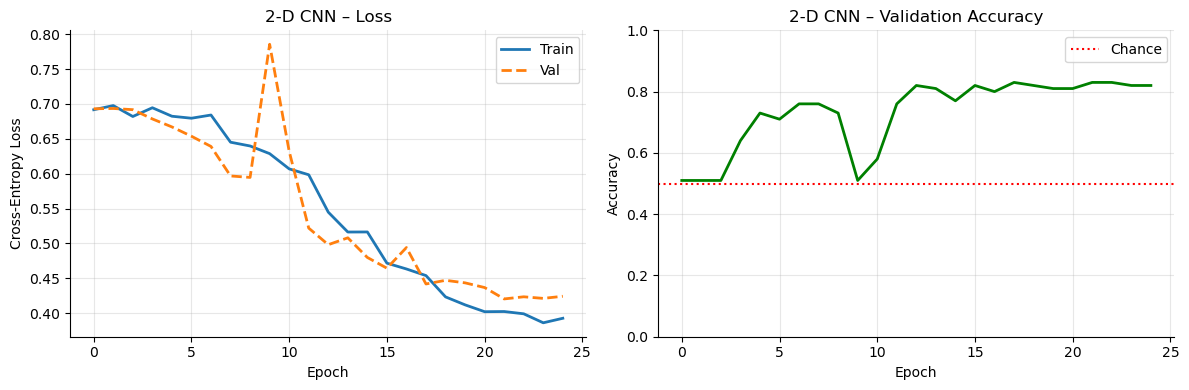

In [17]:
#Training curves:

fig, axes = plt.subplots(1, 2, figsize = (12, 4))

axes[0].plot(hist_cnn2d['train_loss'], label = 'Train', lw = 2)
axes[0].plot(hist_cnn2d['val_loss'],   label = 'Val',   lw = 2, linestyle = '--')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('2-D CNN – Loss'); axes[0].legend(); axes[0].grid(alpha = 0.3)

axes[1].plot(hist_cnn2d['val_acc'], color = 'green', lw = 2)
axes[1].axhline(0.5, color = 'red', linestyle = ':', label = 'Chance')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('2-D CNN – Validation Accuracy'); axes[1].legend()
axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---
## 5. 3-D CNN for Volumetric Classification

A 3-D CNN processes the entire brain volume at once, preserving spatial relationships across all three axes. This is the gold standard for structural MRI analysis but is computationally intensive.

In [18]:
#Volumetric dataset (resampled to 32^3 for speed):

class BrainVolumeDataset(Dataset):
    """Full 3-D brain volume dataset, resampled to a common shape.
    """
    def __init__(self, img_paths, labels, target_shape=(32, 32, 32)):
        self.data = []
        target_affine = np.diag([*[s / t for s, t in
                                    zip(nib.load(img_paths[0]).shape[:3], target_shape)], 1])

        for path, label in zip(img_paths, labels):
            img_r = resample_img(nib.load(path), target_affine = target_affine,
                                 target_shape = target_shape, interpolation = 'continuous')
            vol = img_r.get_fdata().astype(np.float32)
            vol = (vol - vol.mean()) / (vol.std() + 1e-8)
            self.data.append((torch.tensor(vol[np.newaxis]), label))   # (1, D, H, W)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        vol, label = self.data[idx]
        return vol, torch.tensor(label, dtype = torch.long)


print('Building volumetric dataset (may take ~1 min)…')
vol_ds = BrainVolumeDataset(oasis.gray_matter_maps, labels_oasis, target_shape = (32, 32, 32))
print(f'Volume shape: {vol_ds[0][0].shape}')

Building volumetric dataset (may take ~1 min)…
Volume shape: torch.Size([1, 32, 32, 32])


In [19]:
#3-D CNN architecture:

class BrainCNN3D(nn.Module):
    """Lightweight 3-D CNN for volumetric brain classification.
    """
    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1  32→16
            nn.Conv3d(1, 16, 3, padding=1), nn.BatchNorm3d(16), nn.ReLU(),
            nn.MaxPool3d(2),
            # Block 2  16→8
            nn.Conv3d(16, 32, 3, padding=1), nn.BatchNorm3d(32), nn.ReLU(),
            nn.MaxPool3d(2),
            # Block 3  8→4
            nn.Conv3d(32, 64, 3, padding=1), nn.BatchNorm3d(64), nn.ReLU(),
            nn.MaxPool3d(2),
            nn.AdaptiveAvgPool3d((2, 2, 2)),)
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8, 128), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(128, num_classes),)

    def forward(self, x):
        return self.classifier(self.features(x))


cnn3d_proto = BrainCNN3D()
print(f'3-D CNN trainable params: {count_params(cnn3d_proto):,}')

# Sanity-check forward pass
dummy = torch.zeros(2, 1, 32, 32, 32)
print(f'Output shape on dummy batch: {cnn3d_proto(dummy).shape}')

3-D CNN trainable params: 135,810
Output shape on dummy batch: torch.Size([2, 2])


In [20]:
#Training the 3-D CNN:

print('Training 3-D CNN (small dataset, ~1 min on CPU)')
cnn3d, hist_cnn3d = train_model(BrainCNN3D(), vol_ds, epochs = 30, batch_size = 8, lr = 1e-3)

Training 3-D CNN (small dataset, ~1 min on CPU)
  Epoch 05/30 train_loss=0.6453  val_loss=1.0691  val_acc=0.100
  Epoch 10/30 train_loss=0.6975  val_loss=0.8210  val_acc=0.100
  Epoch 15/30 train_loss=0.6380  val_loss=0.8407  val_acc=0.100
  Epoch 20/30 train_loss=0.5179  val_loss=0.9049  val_acc=0.100
  Epoch 25/30 train_loss=0.3417  val_loss=0.6694  val_acc=0.800
  Epoch 30/30 train_loss=0.3140  val_loss=0.6900  val_acc=0.700


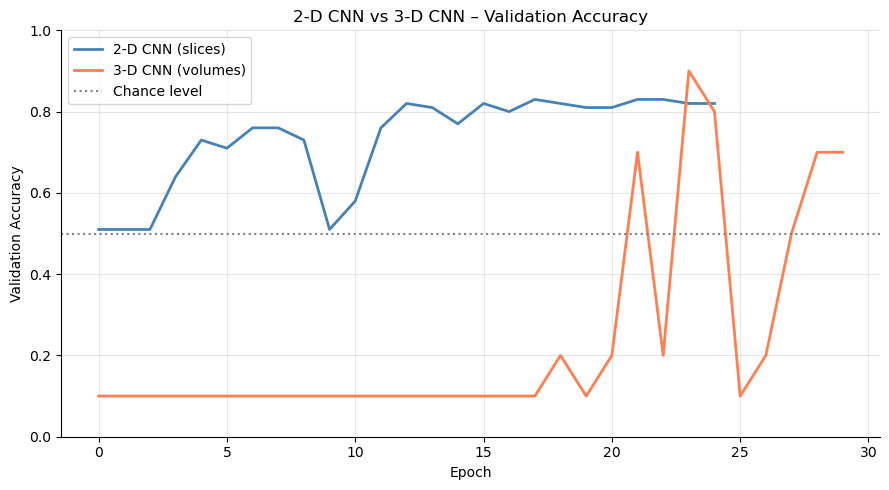

In [21]:
#Comparing 2-D vs 3-D training curves:

fig, ax = plt.subplots(figsize = (9, 5))
ax.plot(hist_cnn2d['val_acc'], label='2-D CNN (slices)', lw=2, color = 'steelblue')
ax.plot(hist_cnn3d['val_acc'], label='3-D CNN (volumes)', lw=2, color = 'coral')
ax.axhline(0.5, color='grey', linestyle=':', label='Chance level')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_title('2-D CNN vs 3-D CNN – Validation Accuracy'); ax.legend()
ax.set_ylim(0, 1); ax.grid(alpha = 0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 6. Transfer Learning: Adapting ResNet-18 to MRI Slices

Pretrained ImageNet models can be fine-tuned for brain MRI via two strategies: feature extraction (small dataset; freeze all but the head) and fine-tuning (larger dataset; update the whole network with a low LR).

In [22]:
#Dataset adapter: 1-channel -> 3-channel:

class SliceDatasetRGB(Dataset):

    def __init__(self, base_ds, imagenet_normalize = True):
        self.base = base_ds
        self.norm = transforms.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225]
        ) if imagenet_normalize else nn.Identity()

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_t, label = self.base[idx]       # (1, H, W)
        img_rgb = img_t.repeat(3, 1, 1)    # (3, H, W)
        img_rgb = self.norm(img_rgb)
        return img_rgb, label


rgb_ds = SliceDatasetRGB(slice_ds)
print(f'RGB slice shape: {rgb_ds[0][0].shape}')

RGB slice shape: torch.Size([3, 64, 64])


In [23]:
#Building fine-tune model from ResNet-18:

def build_resnet18_finetune(num_classes=2, feature_extract=True):
    """
    Load pretrained ResNet-18 and replace the final fc layer.
    feature_extract=True → freeze backbone, train head only.
    """
    model = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)

    if feature_extract:
        for param in model.parameters():
            param.requires_grad = False

    #Replace final classifier
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_feat, num_classes)
    )
    return model


resnet = build_resnet18_finetune(feature_extract=True)
trainable = sum(p.numel() for p in resnet.parameters() if p.requires_grad)
total     = sum(p.numel() for p in resnet.parameters())
print(f'Trainable / Total params: {trainable:,} / {total:,}')

Trainable / Total params: 1,026 / 11,177,538


In [24]:
#Training ResNet-18 (feature extraction):

print('Training ResNet-18 feature extractor…')
resnet, hist_resnet = train_model(
    build_resnet18_finetune(feature_extract = True),
    rgb_ds, epochs = 20, batch_size = 32, lr = 1e-3)

Training ResNet-18 feature extractor…
  Epoch 05/20 train_loss=0.7887  val_loss=0.6715  val_acc=0.640
  Epoch 10/20 train_loss=0.6075  val_loss=0.6051  val_acc=0.660
  Epoch 15/20 train_loss=0.5752  val_loss=0.6054  val_acc=0.710
  Epoch 20/20 train_loss=0.5626  val_loss=0.6081  val_acc=0.700


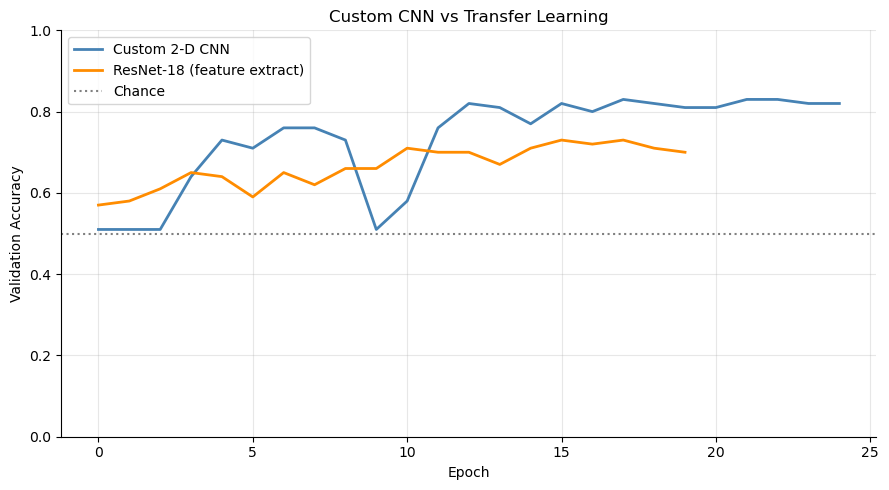

In [25]:
#Comparing custom CNN vs Transfer Learning:

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(hist_cnn2d['val_acc'],   label='Custom 2-D CNN', lw = 2, color = 'steelblue')
ax.plot(hist_resnet['val_acc'],  label='ResNet-18 (feature extract)', lw=2, color = 'darkorange')
ax.axhline(0.5, color='grey', linestyle=':', label='Chance')
ax.set_xlabel('Epoch'); ax.set_ylabel('Validation Accuracy')
ax.set_title('Custom CNN vs Transfer Learning'); ax.legend()
ax.set_ylim(0, 1); ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

---
## 7. Evaluation and Model Comparison

Finally, we use ROC curves and confusion matrices for evaluation.

In [26]:
#Collect predictions from 2-D CNN on the slice dataset:

def get_predictions(model, dataset, batch_size=64):
    model.eval()
    dl = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in dl:
            probs = torch.softmax(model(xb.to(DEVICE)), dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.numpy())
    return np.concatenate(all_probs), np.concatenate(all_labels)


probs_2d, labels_2d = get_predictions(cnn2d,   slice_ds)
probs_tf, labels_tf = get_predictions(resnet,   rgb_ds)

# Threshold at 0.5
preds_2d = (probs_2d > 0.5).astype(int)
preds_tf = (probs_tf > 0.5).astype(int)

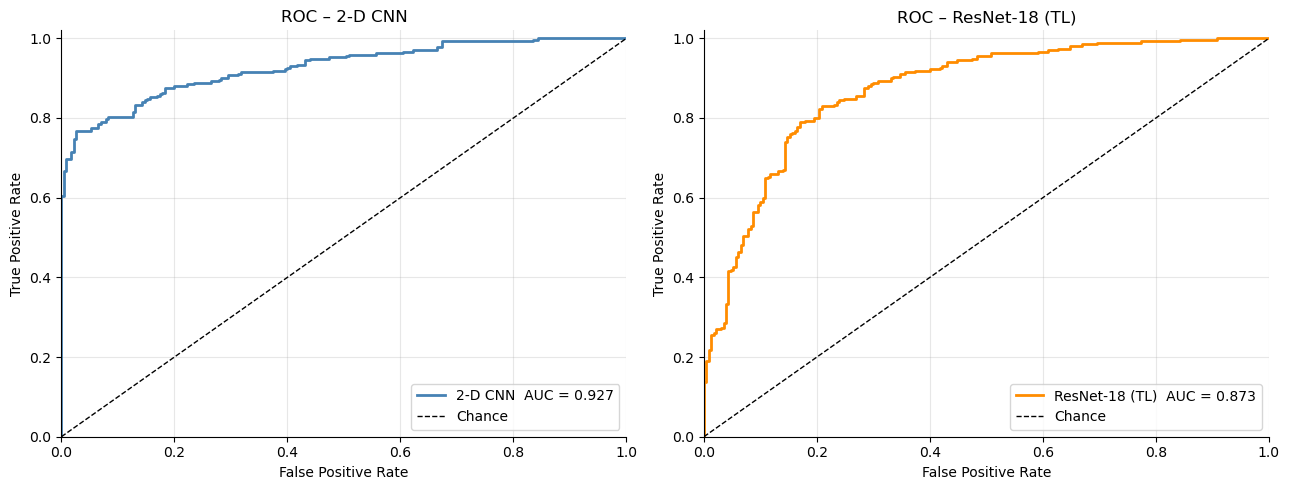

In [27]:
#ROC curves:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (probs, labels, name, colour) in zip(axes, [
    (probs_2d, labels_2d, '2-D CNN',              'steelblue'),
    (probs_tf, labels_tf, 'ResNet-18 (TL)',        'darkorange'),
]):
    fpr, tpr, _ = roc_curve(labels, probs)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=colour, label = f'{name}  AUC = {roc_auc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Chance')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC – {name}'); ax.legend(loc = 'lower right')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02); ax.grid(alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

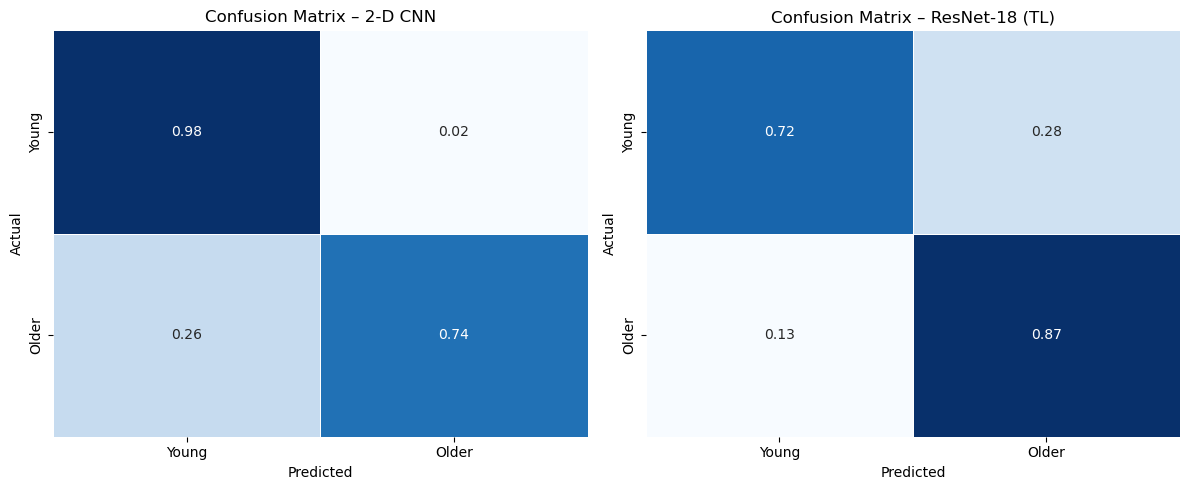


--- Classification Report (2-D CNN) ---
              precision    recall  f1-score   support

       Young       0.76      0.98      0.86       230
       Older       0.98      0.74      0.84       270

    accuracy                           0.85       500
   macro avg       0.87      0.86      0.85       500
weighted avg       0.88      0.85      0.85       500



In [28]:
#Confusion matrices:

fig, axes = plt.subplots(1, 2, figsize = (12, 5))
class_names = ['Young', 'Older']

for ax, (preds, labels, title) in zip(axes, [
    (preds_2d, labels_2d, '2-D CNN'),
    (preds_tf, labels_tf, 'ResNet-18 (TL)'),]):
    
    cm = confusion_matrix(labels, preds, normalize = 'true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap = 'Blues', ax = ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, cbar = False)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix – {title}')

plt.tight_layout()
plt.show()

print('\n--- Classification Report (2-D CNN) ---')
print(classification_report(labels_2d, preds_2d, target_names = class_names))